In [2]:
%load_ext autoreload
%autoreload 2
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.lines as mlines
from src.loading import *
from src.saving import *
from src.sectors import SECTORS

In [3]:
def _format_plot(ax):
    # Set title font size
    #
    ax.title.set_fontsize(14)
    # Set axis label font size
    #
    ax.xaxis.label.set_size(12)
    ax.yaxis.label.set_size(12)
    ax.tick_params(axis='both', which='major', labelsize=12)

# Circulation differences

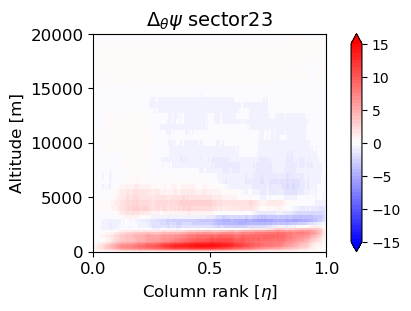

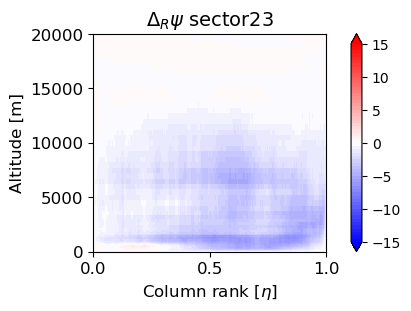

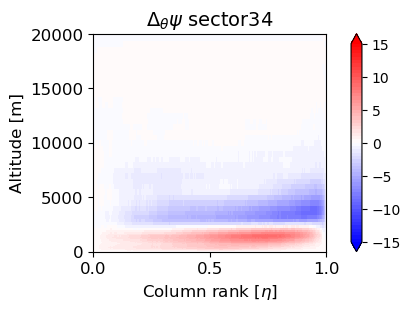

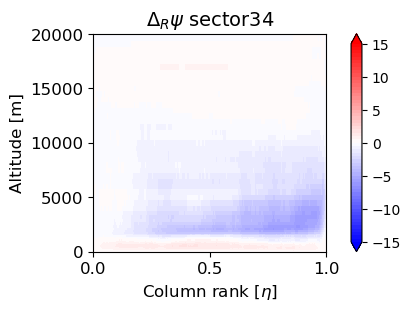

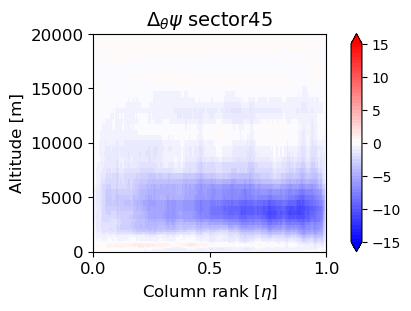

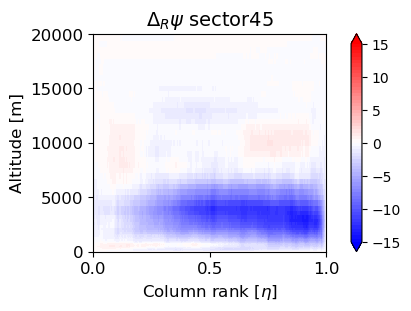

In [4]:
cmap = plt.cm.bwr
lev_min, lev_max, delta_lev = -15, 15, 0.5
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)
# Choose sector to plot
#
for sector_name, sector in SECTORS.items():
    # First delta theta
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_circ = (
        (load_evolution_composite_anomaly('wa', sector_name, 'pos_delta_theta') * load_gsam_reference_profiles()['rho']).cumsum('column') - 
        (load_evolution_composite_anomaly('wa', sector_name, 'neg_delta_theta') * load_gsam_reference_profiles()['rho']).cumsum('column')
    )
    delta_circ.coarsen({'column': 10}).mean().plot(ax=ax, y='z', levels=levels, cmap=cmap, norm=norm, extend='both', cbar_kwargs={'label': None})
    ax.set_title(rf'$\Delta_\theta\psi$ {sector_name}')
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _format_plot(ax)
    save_figure(fig, f'delta_streamfunction_delta_theta_{sector_name}.pdf')
    # Next delta radius
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_circ = (
        (load_evolution_composite_anomaly('wa', sector_name, 'pos_delta_radius') * load_gsam_reference_profiles()['rho']).cumsum('column') - 
        (load_evolution_composite_anomaly('wa', sector_name, 'neg_delta_radius') * load_gsam_reference_profiles()['rho']).cumsum('column')
    )
    delta_circ.coarsen({'column': 10}).mean().plot(ax=ax, y='z', levels=levels, cmap=cmap, norm=norm, extend='both', cbar_kwargs={'label': None})
    ax.set_title(rf'$\Delta_R\psi$ {sector_name}')    
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _format_plot(ax)
    save_figure(fig, f'delta_streamfunction_delta_radius_{sector_name}.pdf')

# MSE

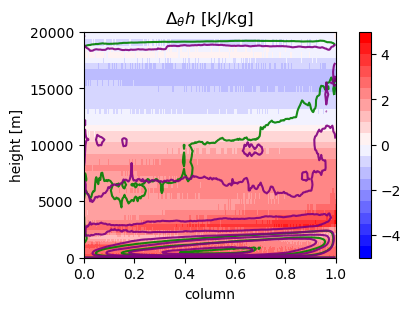

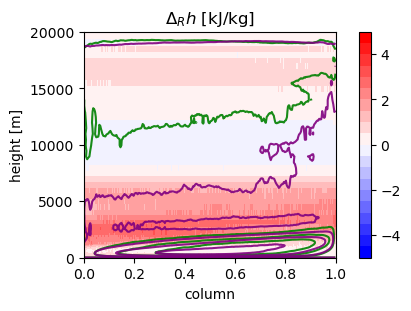

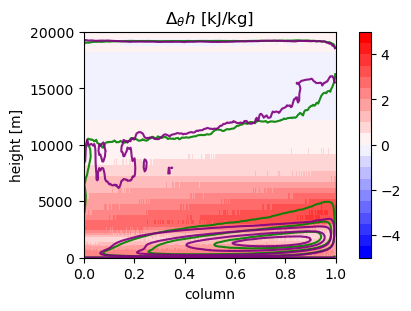

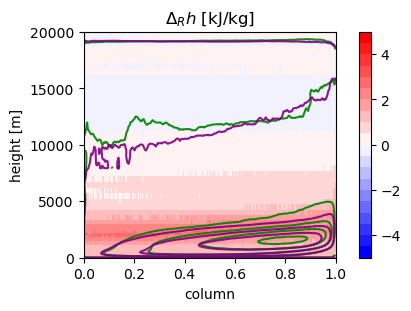

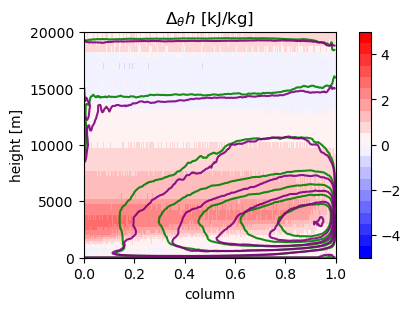

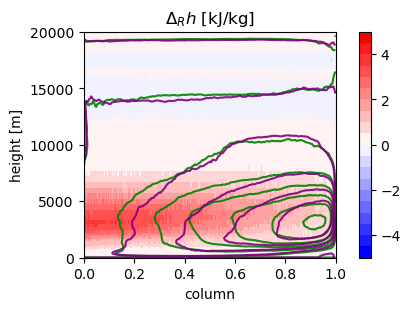

In [19]:
def _mse(trans_type, sector_name):
    qv = 1e-3*load_evolution_composite('hus', sector_name, trans_type)
    t = load_evolution_composite('ta', sector_name, trans_type)
    gz = load_gsam_reference_profiles().z * 9.81
    mse = ((1004 * t) + (2.5e6 * qv) + gz) / 1000
    return mse

def _plot_circ(ax, trans_type, sector_name, colors='black', alpha=0.9):
    mf = (
    load_evolution_composite_anomaly('wa', sector_name, trans_type) * 
    load_gsam_reference_profiles().rho
    )
    circ = mf.cumsum('column') * -1
    circ = circ.coarsen({'column': 10}).mean()
    circ.plot.contour(ax=ax, y='z', levels=np.arange(0, 200, 10), colors=colors, alpha=alpha)
    
cmap = plt.cm.bwr
lev_min, lev_max, delta_lev = -5, 5, 0.5
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)

for sector_name, sector in SECTORS.items():
    # Delta theta
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_mse = _mse(f"pos_delta_theta", sector_name) - _mse(f"neg_delta_theta", sector_name)
    delta_mse.coarsen({'column': 10}).mean().plot(
        ax=ax,
        y='z',
        levels=levels,
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': None}
    )
    ax.set_title(rf'$\Delta_\theta h$ {sector_name} [kJ/kg]')
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _plot_circ(ax, 'pos_delta_theta', sector_name, colors='green')
    _plot_circ(ax, 'neg_delta_theta', sector_name, colors='purple')
    ax.set_title(r'$\Delta_\theta h$ [kJ/kg]')
    save_figure(fig, f'delta_mse_delta_theta_{sector_name}.pdf')
    # Delta radius
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_mse = _mse(f"pos_delta_radius", sector_name) - _mse(f"neg_delta_radius", sector_name)
    delta_mse.coarsen({'column': 10}).mean().plot(
        ax=ax,
        y='z',
        levels=levels,
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': None}
    )
    ax.set_title(rf'$\Delta_R h$ {sector_name} [kJ/kg]')
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _plot_circ(ax, 'pos_delta_radius', sector_name, colors='green')
    _plot_circ(ax, 'neg_delta_radius', sector_name, colors='purple')
    ax.set_title(r'$\Delta_R h$ [kJ/kg]')
    save_figure(fig, f'delta_mse_delta_radius_{sector_name}.pdf')

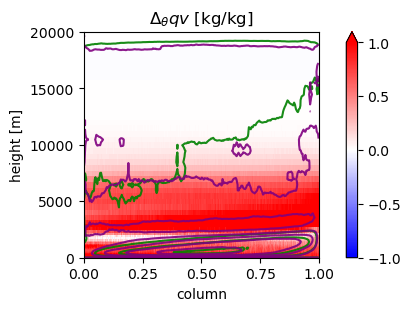

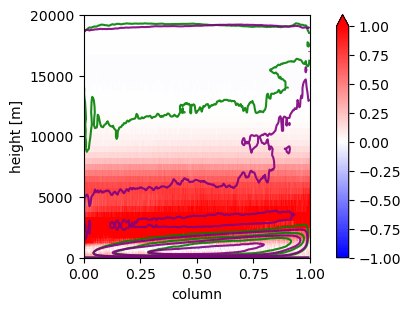

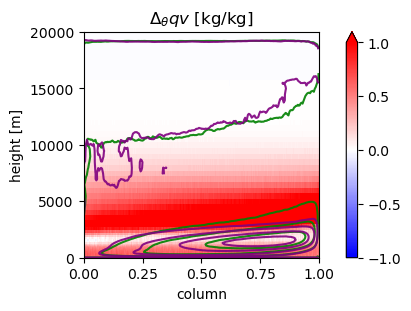

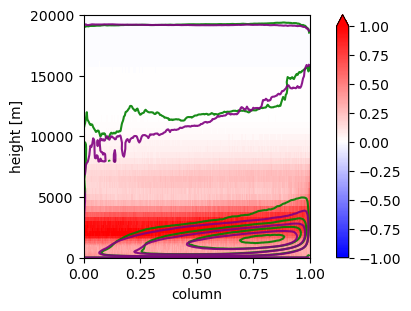

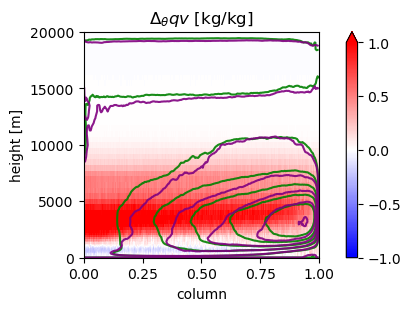

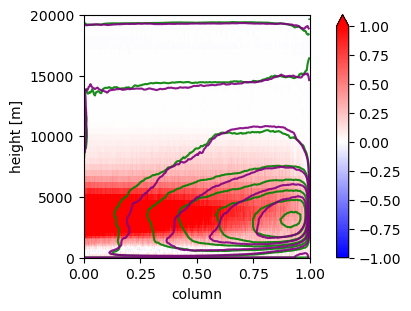

In [15]:
def _mse(trans_type, sector_name):
    qv = load_evolution_composite('hus', sector_name, trans_type)
    t = load_evolution_composite('ta', sector_name, trans_type)
    gz = load_gsam_reference_profiles().z * 9.81
    mse = ((1004 * t) + (2.5e6 * qv) + gz) / 1000
    return qv

def _plot_circ(ax, trans_type, sector_name, colors='black', alpha=0.9):
    mf = (
    load_evolution_composite_anomaly('wa', sector_name, trans_type) * 
    load_gsam_reference_profiles().rho
    )
    circ = mf.cumsum('column') * -1
    circ = circ.coarsen({'column': 10}).mean()
    circ.plot.contour(ax=ax, y='z', levels=np.arange(0, 200, 10), colors=colors, alpha=alpha)
    
cmap = plt.cm.bwr
lev_min, lev_max, delta_lev = -1, 1, 0.01
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)

for sector_name, sector in SECTORS.items():
    # Delta theta
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_mse = _mse(f"pos_delta_theta", sector_name) - _mse(f"neg_delta_theta", sector_name)
    delta_mse.coarsen({'column': 10}).mean().plot(
        ax=ax,
        y='z',
        levels=levels,
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': None}
    )
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _plot_circ(ax, 'pos_delta_theta', sector_name, colors='green')
    _plot_circ(ax, 'neg_delta_theta', sector_name, colors='purple')
    ax.set_title(r'$\Delta_\theta qv$ [kg/kg]')
    # Delta radius
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_mse = _mse(f"pos_delta_radius", sector_name) - _mse(f"neg_delta_radius", sector_name)
    delta_mse.coarsen({'column': 10}).mean().plot(
        ax=ax,
        y='z',
        levels=levels,
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': None}
    )
    ax.set_title(rf'$\Delta_R qv$ {sector_name} [kg/kg]')
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _plot_circ(ax, 'pos_delta_radius', sector_name, colors='green')
    _plot_circ(ax, 'neg_delta_radius', sector_name, colors='purple')


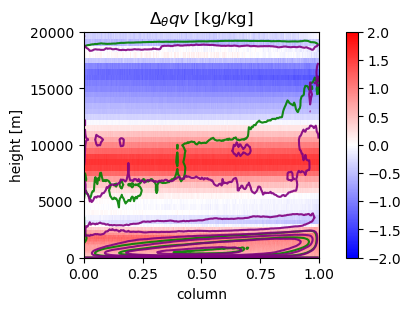

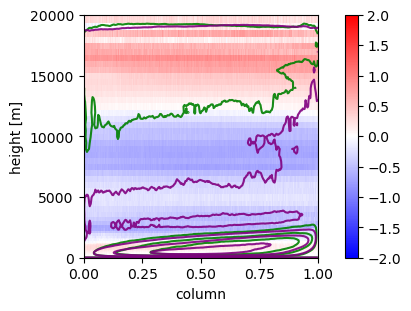

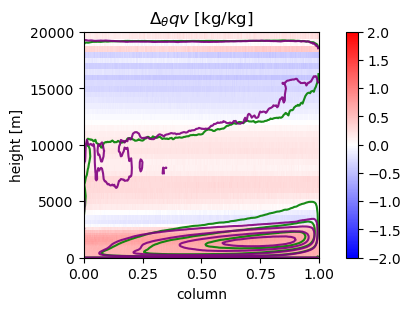

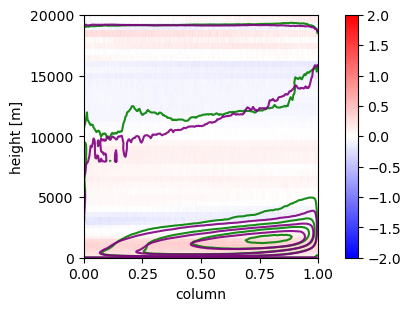

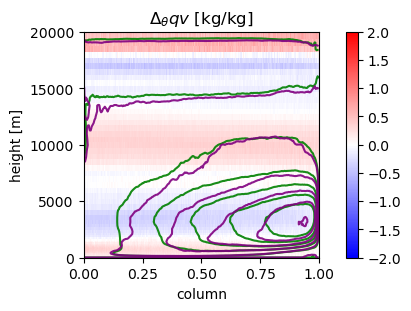

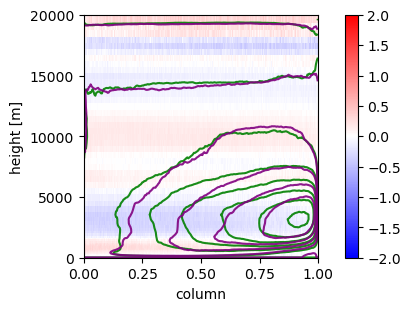

In [18]:
def _mse(trans_type, sector_name):
    qv = load_evolution_composite('hus', sector_name, trans_type)
    t = load_evolution_composite('ta', sector_name, trans_type)
    gz = load_gsam_reference_profiles().z * 9.81
    mse = ((1004 * t) + (2.5e6 * qv) + gz) / 1000
    return t

def _plot_circ(ax, trans_type, sector_name, colors='black', alpha=0.9):
    mf = (
    load_evolution_composite_anomaly('wa', sector_name, trans_type) * 
    load_gsam_reference_profiles().rho
    )
    circ = mf.cumsum('column') * -1
    circ = circ.coarsen({'column': 10}).mean()
    circ.plot.contour(ax=ax, y='z', levels=np.arange(0, 200, 10), colors=colors, alpha=alpha)
    
cmap = plt.cm.bwr
lev_min, lev_max, delta_lev = -2, 2, 0.01
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)

for sector_name, sector in SECTORS.items():
    # Delta theta
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_mse = _mse(f"pos_delta_theta", sector_name) - _mse(f"neg_delta_theta", sector_name)
    delta_mse.coarsen({'column': 10}).mean().plot(
        ax=ax,
        y='z',
        levels=levels,
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': None}
    )
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _plot_circ(ax, 'pos_delta_theta', sector_name, colors='green')
    _plot_circ(ax, 'neg_delta_theta', sector_name, colors='purple')
    ax.set_title(r'$\Delta_\theta qv$ [kg/kg]')
    # Delta radius
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_mse = _mse(f"pos_delta_radius", sector_name) - _mse(f"neg_delta_radius", sector_name)
    delta_mse.coarsen({'column': 10}).mean().plot(
        ax=ax,
        y='z',
        levels=levels,
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': None}
    )
    ax.set_title(rf'$\Delta_R qv$ {sector_name} [kg/kg]')
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _plot_circ(ax, 'pos_delta_radius', sector_name, colors='green')
    _plot_circ(ax, 'neg_delta_radius', sector_name, colors='purple')


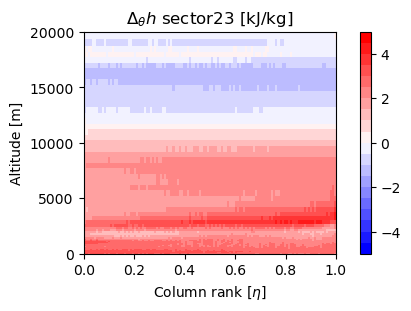

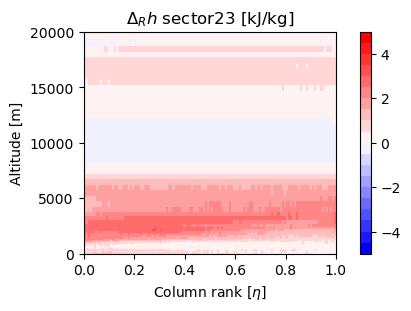

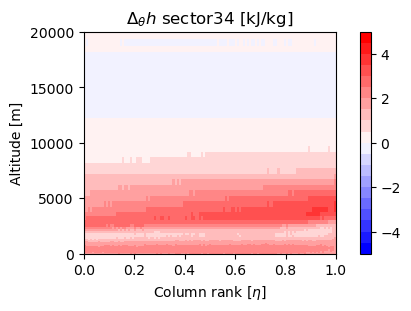

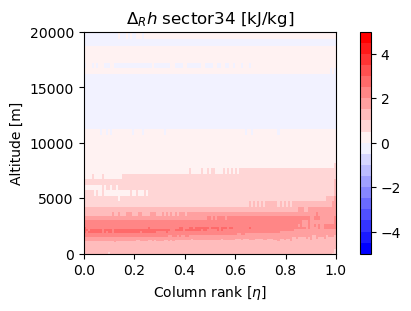

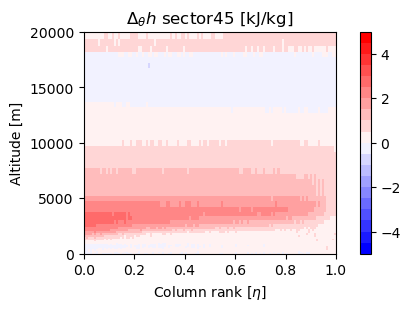

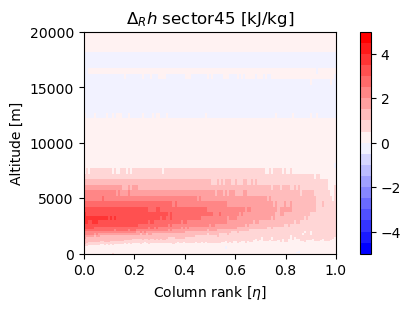

In [ ]:


def _plot_circ(ax, trans_type, sector_name, color):
    w = load_evolution_composite_anomaly('wa', sector_name, trans_type)
    circ = ((w.cumsum('column') * load_gsam_reference_profiles()['rho'])*-1).cumsum('column')
    circ = circ.coarsen({'column': 10}).mean()
    circ.contour(ax=ax, levels=np.arange(10, 200, 10))


cmap = plt.cm.bwr
lev_min, lev_max, delta_lev = -5, 5, 0.5
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)


    trans = 'theta'
    delta_mse = _mse(f"pos_delta_{trans}", sector_name) - _mse(f"neg_delta_{trans}", sector_name)
    delta_mse.coarsen({'column': 20}).mean().plot(
        ax=ax,
        y='z',
        levels=levels,
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': None}
    )
    
    _plot_circ(ax, trans_t)

    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    trans = 'radius'
    delta_mse = _mse(f"pos_delta_{trans}") - _mse(f"neg_delta_{trans}")
    delta_mse.coarsen({'column': 20}).mean().plot(
        ax=ax,
        y='z',
        levels=levels,
        cmap=cmap,
        norm=norm,
        cbar_kwargs={'label': None}
    )
    ax.set_title(rf'$\Delta_R h$ {sector_name} [kJ/kg]')
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')


In [26]:
clean

'\theta'

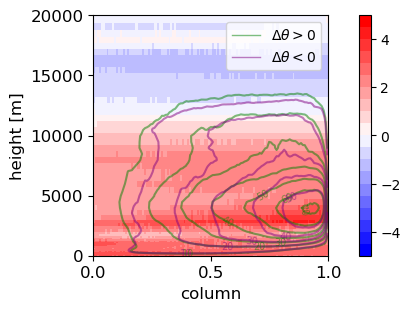

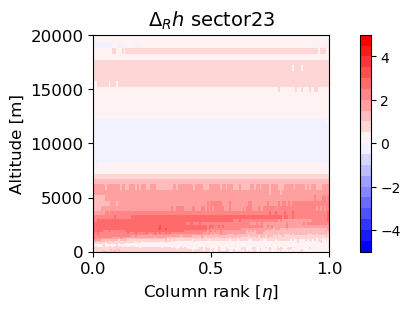

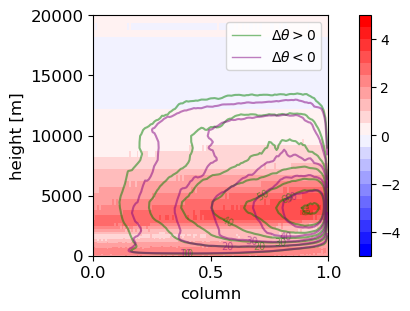

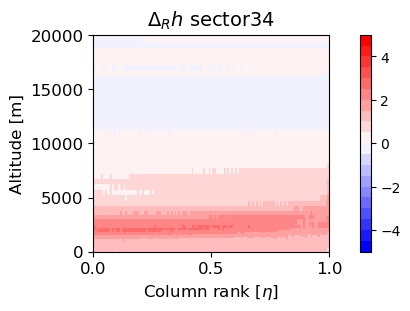

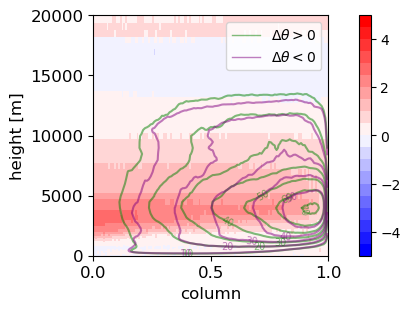

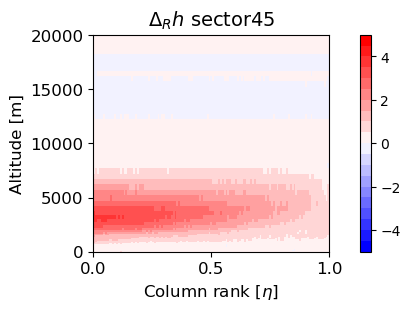

In [ ]:

from matplotlib.lines import Line2D

# Choose sector to plot
#


    # First delta theta
    #
    
     # Plot circulations
    #
    cs_pos = circ_pos.plot.contour(ax=ax, y='z', levels=np.arange(10, 200, 10),
                               colors='green', alpha=0.5)
    ax.clabel(cs_pos, fmt='%d', inline=False, fontsize=7)

    cs_neg = circ_neg.plot.contour(ax=ax, y='z', levels=np.arange(10, 200, 10),
                                colors='purple', alpha=0.5)
    ax.clabel(cs_neg, fmt='%d', inline=False, fontsize=7)

    # Legend proxies
    handles = [
        Line2D([0], [0], color='green',  lw=1, alpha=0.5, label=r'$\Delta\theta>0$'),
        Line2D([0], [0], color='purple', lw=1, alpha=0.5, label=r'$\Delta\theta<0$'),
    ]
    ax.legend(handles=handles)

    _format_plot(ax)
    # save_figure(fig, f'delta_mse_delta_theta_{sector_name}.pdf')
    # Next delta radius
    #
    fig, ax = plt.subplots(figsize=(4,3), constrained_layout=True)
    delta_mse = _mse('pos_delta_radius') - _mse('neg_delta_radius')
    delta_mse.coarsen({'column': 20}).mean().plot(ax=ax, y='z', levels=levels, cmap=cmap, norm=norm, cbar_kwargs={'label': None})
    ax.set_title(rf'$\Delta_R h$ {sector_name}')
    ax.set_xlabel(r'Column rank [$\eta$]')
    ax.set_ylabel('Altitude [m]')
    _format_plot(ax)
    # save_figure(fig, f'delta_mse_delta_radius_{sector_name}.pdf')

# Large-scale Mass Flux

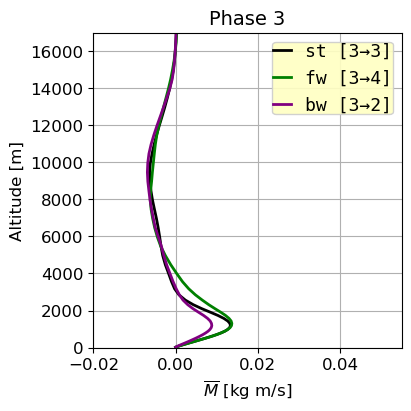

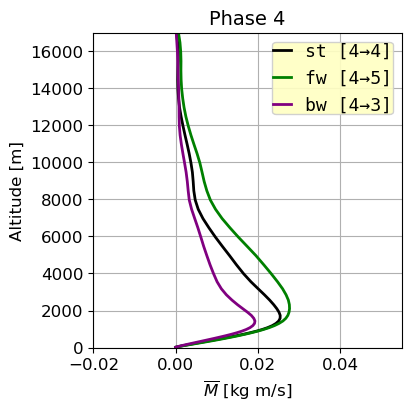

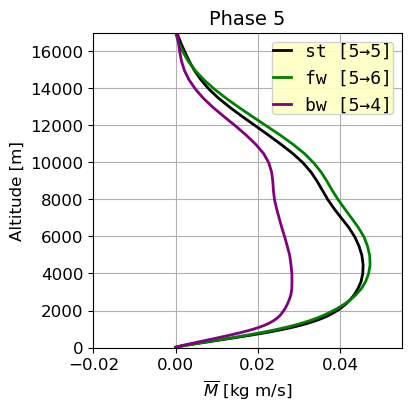

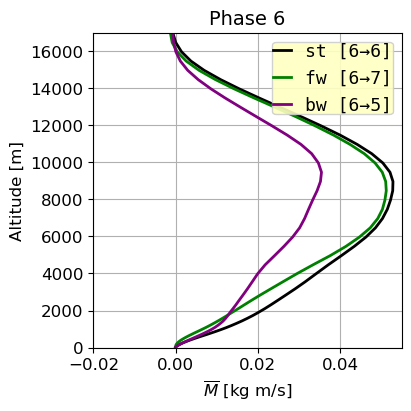

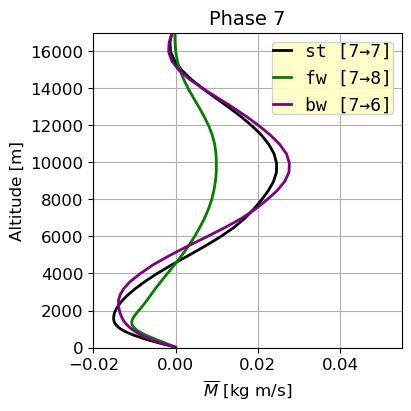

In [10]:
# Plot mean vertical motions
#
for phase in [3, 4, 5, 6, 7]:
    fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
    for trans_type, color, delta in zip(['st', 'fw', 'bw'], ['black', 'green', 'purple'], [0, 1, -1]):
        w = load_phase_transition_composite_mean('wa', phase, trans_type)
        mass_flux = w * load_gsam_reference_profiles().rho
        mass_flux.plot(ax=ax, y='z', label=f'{trans_type} [{phase}→{phase+delta}]', color=color, lw=2)
    ax.set_xlim(-0.02, 0.055)
    ax.set_ylabel('Altitude [m]')
    ax.set_xlabel(r'$\overline{M}$ [kg m/s]')
    # ax.set_xlabel(None)
    ax.legend(
        prop={'family': 'monospace', 'size': 13},
        handlelength=1,
        loc='upper right',
        borderpad=0.02,
        facecolor='xkcd:cream',
        framealpha=0.9)
    ax.grid()
    # ax.set_title(f'Phase {phase}'+ "\n" + r"$\bar{M}$ [kg m/s]")
    ax.set_title(f'Phase {phase}')
    ax.set_ylim(0, 17e3)
    _format_plot(ax)
    save_figure(fig, f'large-scale_M_comparison_phase{phase}.pdf')


# Large-scale Temperature profiles

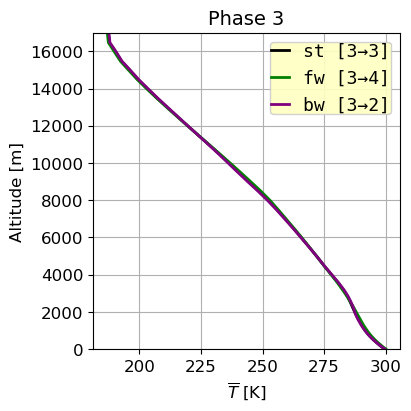

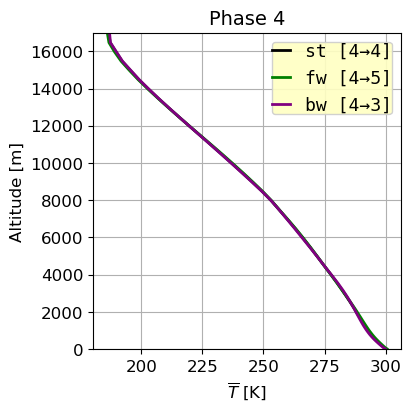

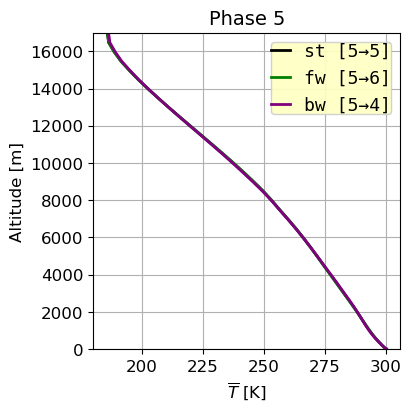

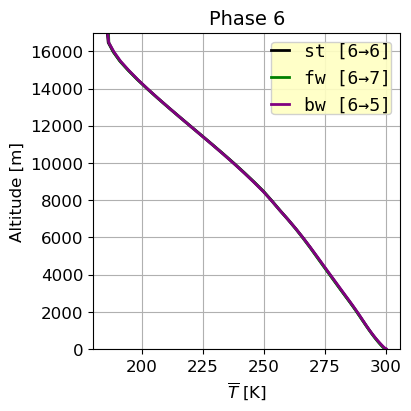

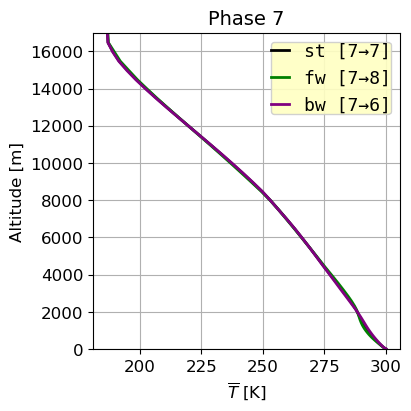

In [9]:
# Plot mean vertical motions
#
for phase in [3, 4, 5, 6, 7]:
    fig, ax = plt.subplots(figsize=(4,4), constrained_layout=True)
    for trans_type, color, delta in zip(['st', 'fw', 'bw'], ['black', 'green', 'purple'], [0, 1, -1]):
        ta = load_phase_transition_composite('ta', phase, trans_type)
        ta.mean('column').plot(ax=ax, y='z', label=f'{trans_type} [{phase}→{phase+delta}]', color=color, lw=2)
    ax.set_ylabel('Altitude [m]')
    ax.set_xlabel(r'$\overline{T}$ [K]')
    # ax.set_xlabel(None)
    ax.legend(
        prop={'family': 'monospace', 'size': 13},
        handlelength=1,
        loc='upper right',
        borderpad=0.02,
        facecolor='xkcd:cream',
        framealpha=0.9)
    ax.grid()
    # ax.set_title(f'Phase {phase}'+ "\n" + r"$\bar{M}$ [kg m/s]")
    ax.set_title(f'Phase {phase}')
    ax.set_ylim(0, 17e3)
    _format_plot(ax)
    # save_figure(fig, f'large-scale_M_comparison_phase{phase}.pdf')


# Differences in small-scale

## Condensate

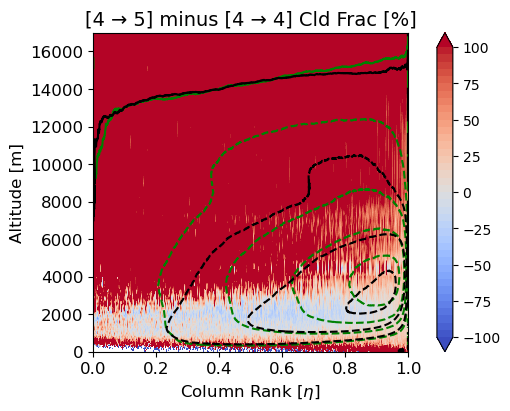

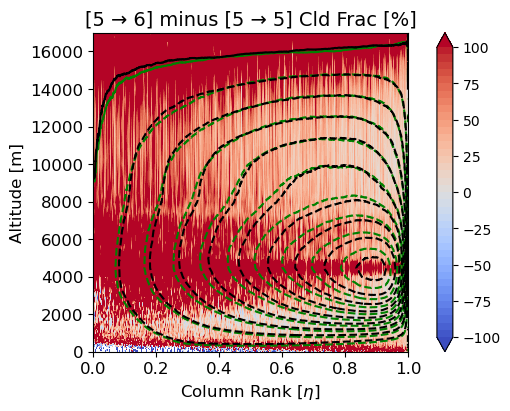

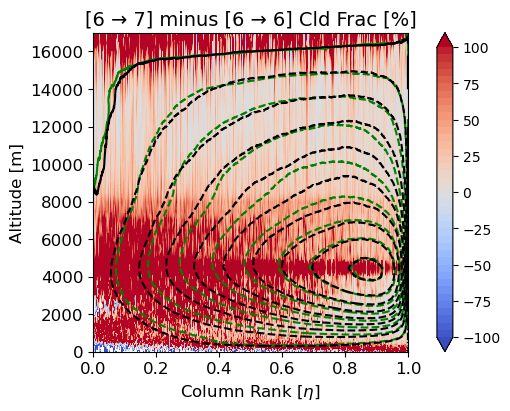

In [104]:
# Plot mean circulation and cloud fractions
#
cmap = plt.cm.coolwarm
lev_min, lev_max, delta_lev = -100, 100, 5
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)
for phase in [4, 5, 6]:
    fig, ax = plt.subplots(figsize=(5,4), constrained_layout=True)
    # Plot delta cloud fraction
    #
    fw = load_phase_transition_composite('cli', phase, 'fw') #+ load_phase_transition_composite('clw', phase, 'fw')
    st = load_phase_transition_composite('cli', phase, 'st') #+ load_phase_transition_composite('clw', phase, 'st')
    delta = 100*(fw - st)/st
    delta = delta.coarsen({'column': 1}).mean()
    delta.plot.contourf(ax=ax, y='z', levels=levels, norm=norm, cmap=cmap, extend='both', cbar_kwargs={'label': None})
    for trans_type, color in zip(['fw', 'st'], ['green', 'black']):
        # Plot circulations
        #
        w = load_phase_transition_composite_anomaly('wa', phase, trans_type)
        circ = w.cumsum('column')
        circ.plot.contour(ax=ax, y='z', levels=np.linspace(-150, 0, 10), colors=color)
    ax.set_ylim(0, 17e3)
    ax.set_title(f'[{phase} → {phase+1}] minus [{phase} → {phase}] Cld Frac [%]')
    ax.set_ylabel('Altitude [m]')
    ax.set_xlabel(r'Column Rank $[\eta]$')
    _format_plot(ax)
    # save_figure(fig, f'cloudfrac_fw-st_difference_phase{phase}.pdf')


### Cloud fraction

/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'lw'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'lw'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'lw'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'lw'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/

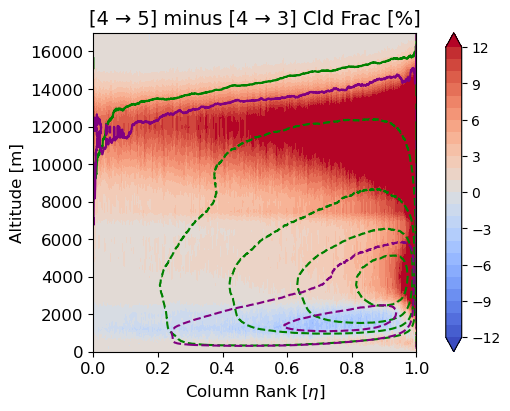

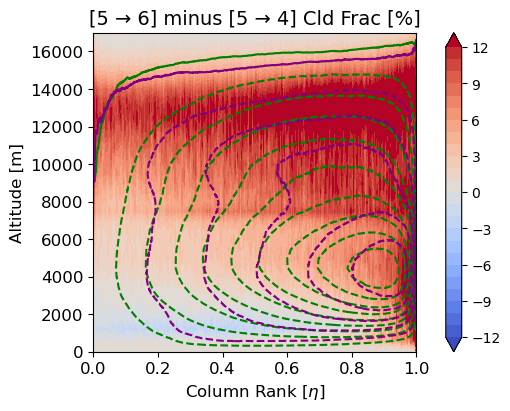

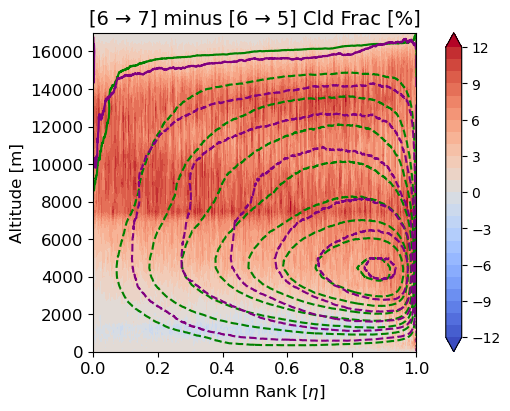

In [ ]:
# Plot mean circulation and cloud fractions
#
cmap = plt.cm.coolwarm
lev_min, lev_max, delta_lev = -12, 12, 1
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)
for phase in [4, 5, 6]:
    fig, ax = plt.subplots(figsize=(5,4), constrained_layout=True)
    # Plot delta cloud fraction
    #
    fw_cf = load_phase_transition_composite('cloudfrac', phase, 'fw')
    bw_cf = load_phase_transition_composite('cloudfrac', phase, 'bw')
    delta = 100*(fw_cf - bw_cf)
    delta = delta.coarsen({'column': 5}).mean()
    delta.plot.contourf(ax=ax, y='z', levels=levels, norm=norm, cmap=cmap, extend='both', cbar_kwargs={'label': None})
    for trans_type, color in zip(['fw', 'bw'], ['green', 'purple']):
        # Plot circulations
        #
        w = load_phase_transition_composite_anomaly('wa', phase, trans_type)
        circ = w.cumsum('column')
        circ.plot.contour(ax=ax, y='z', levels=np.linspace(-150, 0, 10), colors=color, lw=2)
    ax.set_ylim(0, 17e3)
    ax.set_title(f'[{phase} → {phase+1}] minus [{phase} → {phase-1}] Cld Frac [%]')
    ax.set_ylabel('Altitude [m]')
    ax.set_xlabel(r'Column Rank $[\eta]$')
    _format_plot(ax)
    save_figure(fig, f'cloudfrac_difference_phase{phase}.pdf')


/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'label'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/si

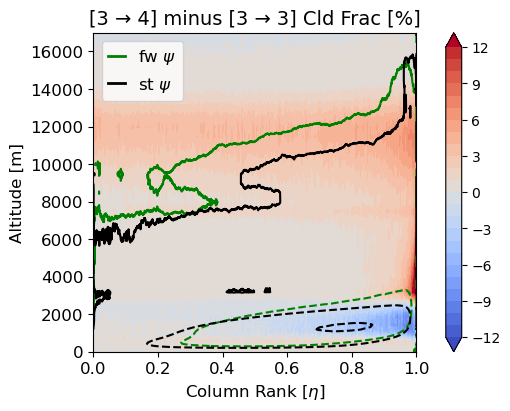

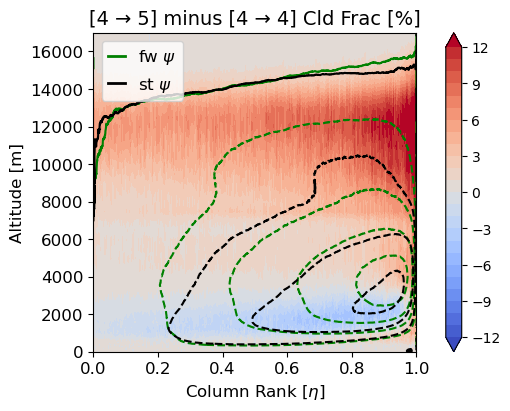

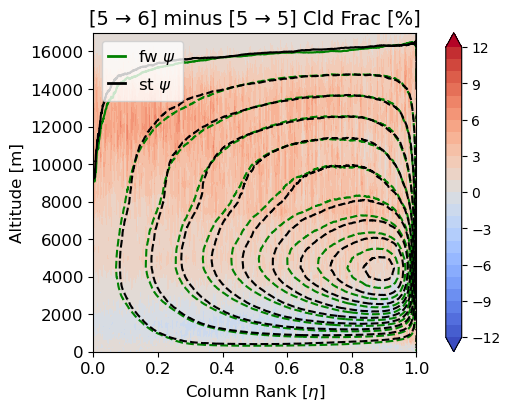

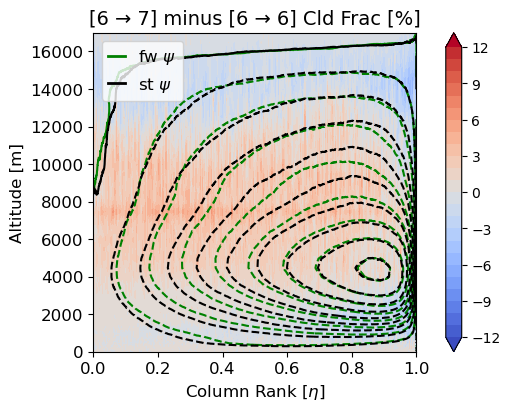

In [118]:
# Plot mean circulation and cloud fractions
#
cmap = plt.cm.coolwarm
lev_min, lev_max, delta_lev = -12, 12, 1
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)
for phase in [3, 4, 5, 6]:
    fig, ax = plt.subplots(figsize=(5,4), constrained_layout=True)
    # Plot delta cloud fraction
    #
    fw_cf = load_phase_transition_composite('cloudfrac', phase, 'fw')
    st_cf = load_phase_transition_composite('cloudfrac', phase, 'st')
    delta = 100*(fw_cf - st_cf)
    delta = delta.coarsen({'column': 5}).mean()
    delta.plot.contourf(ax=ax, y='z', levels=levels, norm=norm, cmap=cmap, extend='both', cbar_kwargs={'label': None})
    for trans_type, color in zip(['fw', 'st'], ['green', 'black']):
        # Plot circulations
        #
        w = load_phase_transition_composite_anomaly('wa', phase, trans_type)
        w = w.coarsen({'column': 1}).mean()
        circ = w.cumsum('column')
        circ.plot.contour(ax=ax, y='z', levels=np.linspace(-150, 0, 10), colors=color, label=trans_type)
    ax.set_ylim(0, 17e3)
    ax.set_title(f'[{phase} → {phase+1}] minus [{phase} → {phase}] Cld Frac [%]')
    ax.set_ylabel('Altitude [m]')
    ax.set_xlabel(r'Column Rank $[\eta]$')
    _format_plot(ax)
    handles = [
        mlines.Line2D([], [], color='green', lw=2, label=r'fw $\psi$'),
        mlines.Line2D([], [], color='black', lw=2, label=r'st $\psi$'),
    ]
    ax.legend(handles=handles, loc='upper left', handlelength=1, fontsize=12)
    save_figure(fig, f'cloudfrac_fw-st_difference_phase{phase}.pdf')


## MSE

In [17]:
def _compute_phase_trans_mse(phase, trans):
    q = 1e-3*load_phase_transition_composite('hus', phase, trans)
    t = load_phase_transition_composite('ta', phase, trans)
    gz = (9.81) * load_gsam_reference_profiles().z
    mse = ((1004 * t) + (2.5e6 * q) + gz) / 1000
    return mse

/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'lw'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'lw'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'lw'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/xarray/plot/dataarray_plot.py:2006: UserWarning: The following kwargs were not used by contour: 'lw'
  primitive = ax.contour(x, y, z, **kwargs)
/Users/pedro/miniconda3/envs/scale_interaction_in_gsam/lib/python3.13/site-packages/

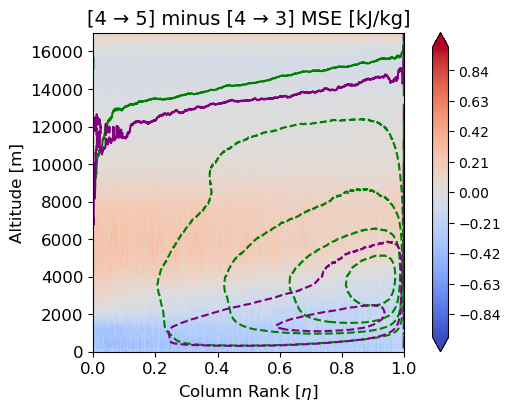

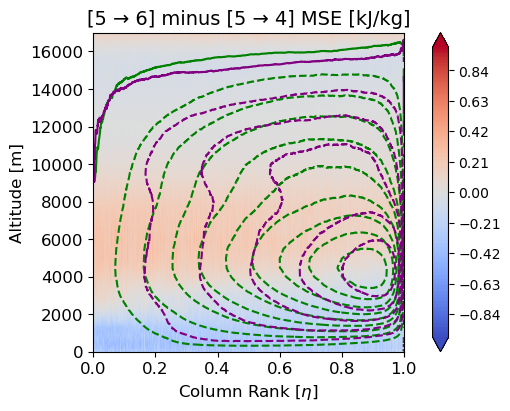

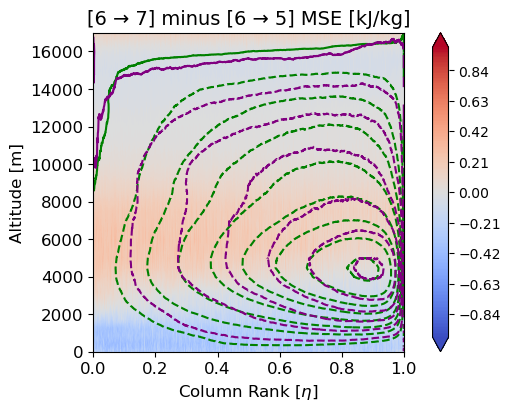

In [23]:
# Plot mean circulation and cloud fractions
#
cmap = plt.cm.coolwarm
lev_min, lev_max, delta_lev = -1, 1, 0.01
norm = colors.TwoSlopeNorm(vmin=lev_min, vcenter=0, vmax=lev_max)
levels = np.arange(lev_min, lev_max + delta_lev, delta_lev)
for phase in [4, 5, 6]:
    fig, ax = plt.subplots(figsize=(5,4), constrained_layout=True)
    # Plot delta cloud fraction
    #
    fw_mse = _compute_phase_trans_mse(phase, 'fw')
    bw_mse = _compute_phase_trans_mse(phase, 'bw')
    delta = delta
    # delta = delta.coarsen({'column': 5}).mean()
    delta.plot.contourf(ax=ax, y='z', levels=levels, norm=norm, cmap=cmap, extend='both', cbar_kwargs={'label': None})
    for trans_type, color in zip(['fw', 'bw'], ['green', 'purple']):
        # Plot circulations
        #
        w = load_phase_transition_composite_anomaly('wa', phase, trans_type)
        circ = w.cumsum('column')
        circ.plot.contour(ax=ax, y='z', levels=np.linspace(-150, 0, 10), colors=color, lw=2)
    ax.set_ylim(0, 17e3)
    ax.set_title(f'[{phase} → {phase+1}] minus [{phase} → {phase-1}] MSE [kJ/kg]')
    ax.set_ylabel('Altitude [m]')
    ax.set_xlabel(r'Column Rank $[\eta]$')
    _format_plot(ax)
    # save_figure(fig, f'cloudfrac_difference_phase{phase}.pdf')


In [16]:
delta

<xarray.DataArray (z: 61, column: 2500)> Size: 610kB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(61, 2500), dtype=float32)
Coordinates:
  * z        (z) float32 244B 20.0 61.2 104.9 ... 1.848e+04 1.905e+04 1.97e+04
  * column   (column) float64 20kB 0.0 0.0004002 0.0008003 ... 0.9992 0.9996 1.0
Attributes:
    long_name:      Absolute Temperature                                     ...
    units:          K         
    cell_methods:   time: mean
    standard_name:  air_temperature
    origin:         TABS